# MIC vs 1/SNR — Per-Family Noise Sensitivity

One line per family: x = 1/SNR (noise level), y = mean MIC across replicates.

Higher x → more noise. SNR=∞ mapped to x=0.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

In [2]:
# ── Settings ──
USE_STRONG   = True
USE_STANDARD = False
USE_MILD     = False
INCLUDE_INF  = True      # include SNR=∞ as x=0
INCLUDE_NULL = False     # include Null family

SHORT = {
    'F01': 'Linear(+)',   'F02': 'Linear(-)',   'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(-)',   'F05': 'PwrCcv(+)',   'F06': 'PwrCcv(-)',
    'F07': 'Sat(+)',      'F08': 'Sat(-)',       'F09': 'Log(+)',
    'F10': 'Log(-)',      'F11': 'Exp(+)',       'F12': 'Exp(-)',
    'F13': 'S-crv(+)',    'F14': 'S-crv(-)',     'F15': 'Thresh(+)',
    'F16': 'Thresh(-)',   'F17': 'Peak',         'F18': 'Valley',
    'F19': 'Spike',       'F20': 'Inv Spike',    'F21': 'Cubic',
    'F22': 'Oscillation', 'F23': 'Two Lines',    'F24': 'L+Parab',
    'F25': 'Multi-reg',   'F26': 'Windowed J',   'Null': 'Null',
}

In [3]:
# ── Load and filter ──
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = ['case_id', 'family_id', 'family_name', 'snr',
             'category', 'variant_level', 'replicate']
meta = cases[[c for c in meta_cols if c in cases.columns]].copy()
df = metrics[['case_id', 'MIC']].merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

allowed_levels = []
if USE_STRONG:   allowed_levels.append('strong')
if USE_STANDARD: allowed_levels.append('standard')
if USE_MILD:     allowed_levels.append('mild')
allowed_levels.append('none')
df = df[df['variant_level'].isin(allowed_levels)].copy()

if not INCLUDE_NULL:
    df = df[df['family_id'] != 'Null'].copy()
if not INCLUDE_INF:
    df = df[df['snr_val'] != float('inf')].copy()

df['inv_snr'] = np.where(df['snr_val'] == float('inf'), 0, 1.0 / df['snr_val'])

snr_max = df['snr_val'].max()
snr_max_str = '∞' if snr_max == float('inf') else f'{snr_max:.0f}'
print(f'Variant levels: {allowed_levels}')
print(f'Families: {sorted(df["family_id"].unique())}')
print(f'SNR levels: {df["snr_val"].nunique()} (range {df["snr_val"].min():.4f} – {snr_max_str})')
print(f'Total cases: {len(df):,}')

Variant levels: ['strong', 'none']
Families: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']
SNR levels: 206 (range 0.0010 – ∞)
Total cases: 53,560


In [4]:
# ── Aggregate: mean MIC per family per SNR ──
agg = df.groupby(['family_id', 'snr_val', 'inv_snr'])['MIC'].mean().reset_index()
agg = agg.sort_values(['family_id', 'inv_snr'])

fids = sorted(agg['family_id'].unique())
print(f'{len(fids)} families, {len(agg)} data points')

26 families, 5356 data points


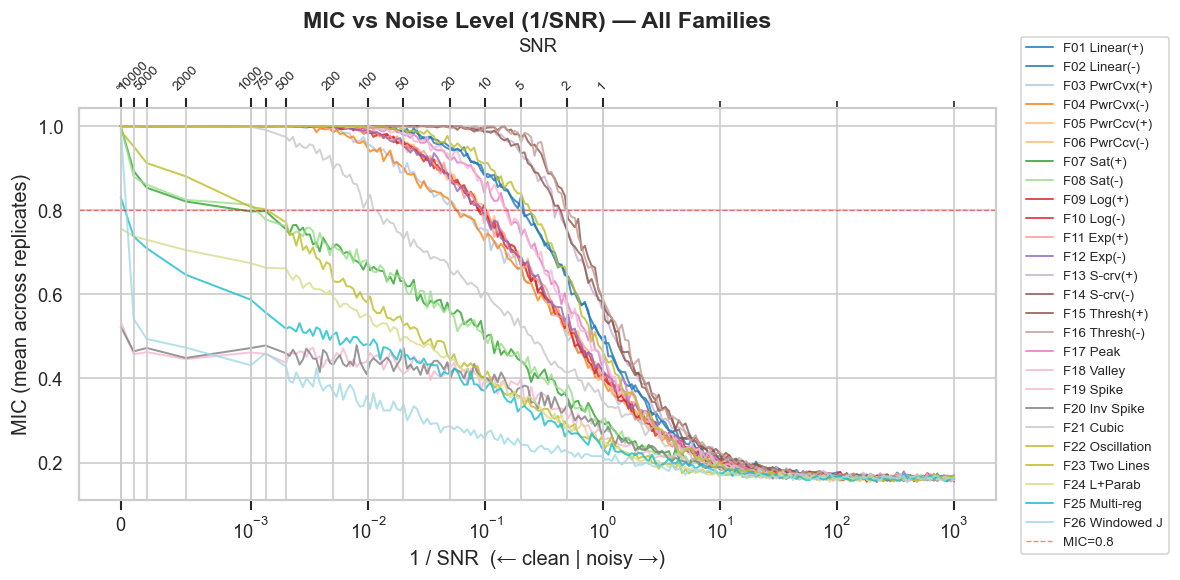

In [11]:
# ── Plot: MIC vs 1/SNR — all families ──
fig, ax = plt.subplots(figsize=(10, 5))

cmap = plt.cm.tab20
colors = {fid: cmap(i / len(fids)) for i, fid in enumerate(fids)}

for fid in fids:
    sub = agg[agg['family_id'] == fid].sort_values('inv_snr')
    label = f'{fid} {SHORT.get(fid, fid)}'
    ax.plot(sub['inv_snr'], sub['MIC'], linewidth=1.2, alpha=0.8,
            color=colors[fid], label=label)

ax.set_xlabel('1 / SNR  (← clean | noisy →)', fontsize=12)
ax.set_ylabel('MIC (mean across replicates)', fontsize=12)
ax.set_title('MIC vs Noise Level (1/SNR) — All Families', fontsize=14, fontweight='bold')

ax.set_xscale('symlog', linthresh=0.001)

# Add SNR reference ticks on top axis (dense near ∞–500 gap)
ax2 = ax.twiny()
snr_refs = [float('inf'), 10000, 5000, 2000, 1000, 750, 500, 200, 100, 50, 20, 10, 5, 2, 1]
inv_refs = [0 if s == float('inf') else 1/s for s in snr_refs]
snr_labels = ['∞' if s == float('inf') else f'{s:g}' for s in snr_refs]
ax2.set_xscale('symlog', linthresh=0.001)
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(inv_refs)
ax2.set_xticklabels(snr_labels, fontsize=8, rotation=45)
ax2.set_xlabel('SNR', fontsize=11)

ax.axhline(y=0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='MIC=0.8')

ax.legend(bbox_to_anchor=(1.02, 1.2), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

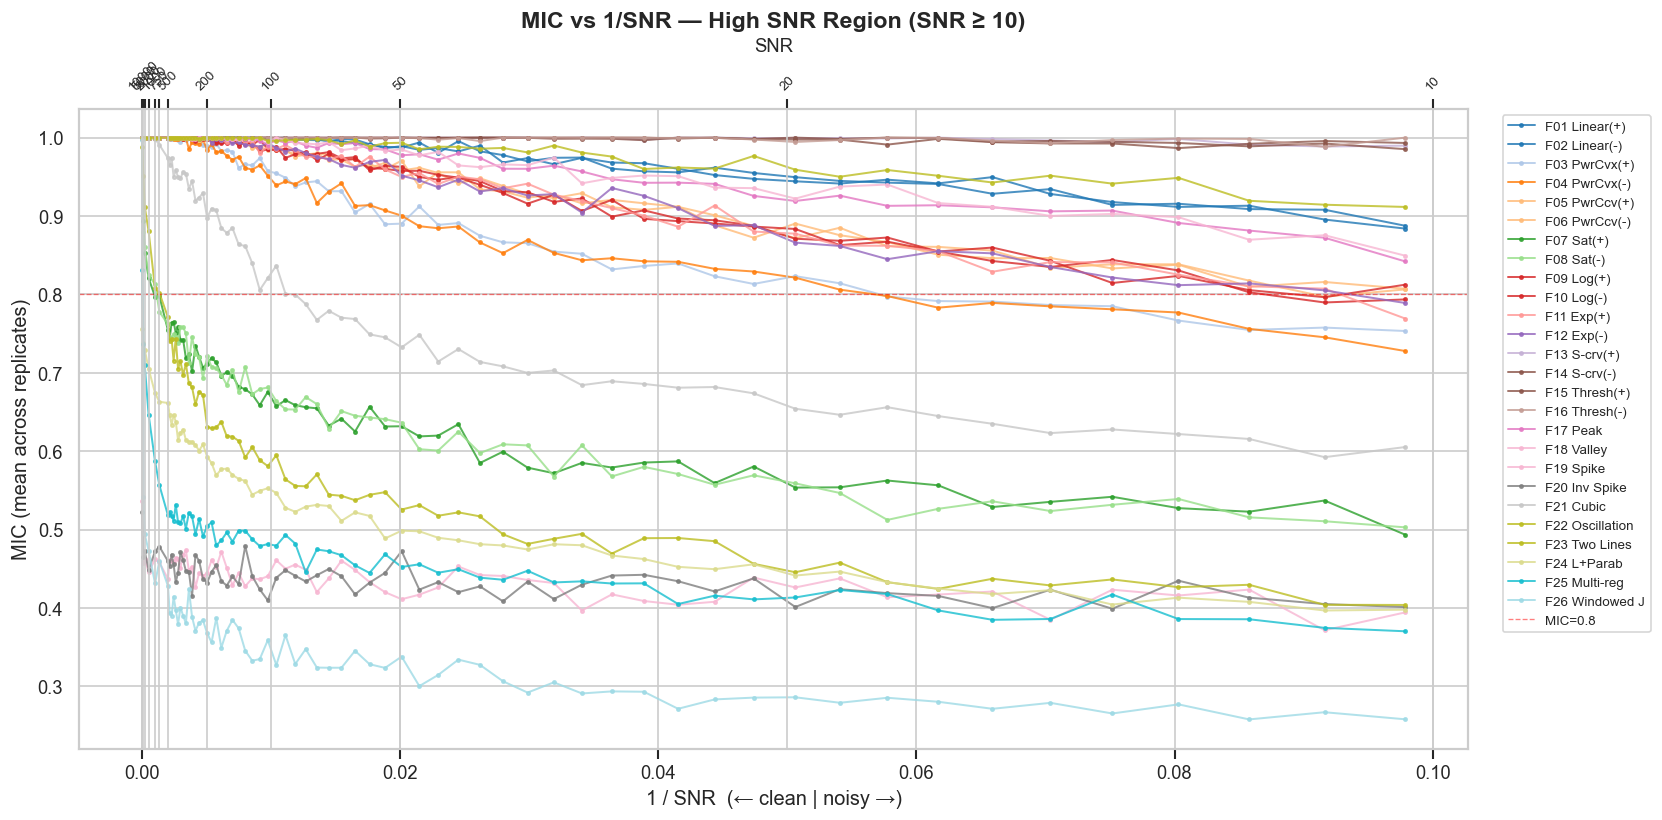

In [6]:
# ── Plot: zoom into high-SNR region (SNR ≥ 10, i.e. 1/SNR ≤ 0.1) ──
fig, ax = plt.subplots(figsize=(14, 7))

for fid in fids:
    sub = agg[(agg['family_id'] == fid) & (agg['inv_snr'] <= 0.1)].sort_values('inv_snr')
    label = f'{fid} {SHORT.get(fid, fid)}'
    ax.plot(sub['inv_snr'], sub['MIC'], linewidth=1.2, alpha=0.8,
            color=colors[fid], label=label, marker='o', markersize=2)

ax.set_xlabel('1 / SNR  (← clean | noisy →)', fontsize=12)
ax.set_ylabel('MIC (mean across replicates)', fontsize=12)
ax.set_title('MIC vs 1/SNR — High SNR Region (SNR ≥ 10)', fontsize=14, fontweight='bold')

ax2 = ax.twiny()
snr_zoom = [float('inf'), 10000, 5000, 2000, 1000, 750, 500, 200, 100, 50, 20, 10]
inv_zoom = [0 if s == float('inf') else 1/s for s in snr_zoom]
snr_zlabels = ['∞' if s == float('inf') else f'{s:g}' for s in snr_zoom]
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(inv_zoom)
ax2.set_xticklabels(snr_zlabels, fontsize=8, rotation=45)
ax2.set_xlabel('SNR', fontsize=11)

ax.axhline(y=0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='MIC=0.8')

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

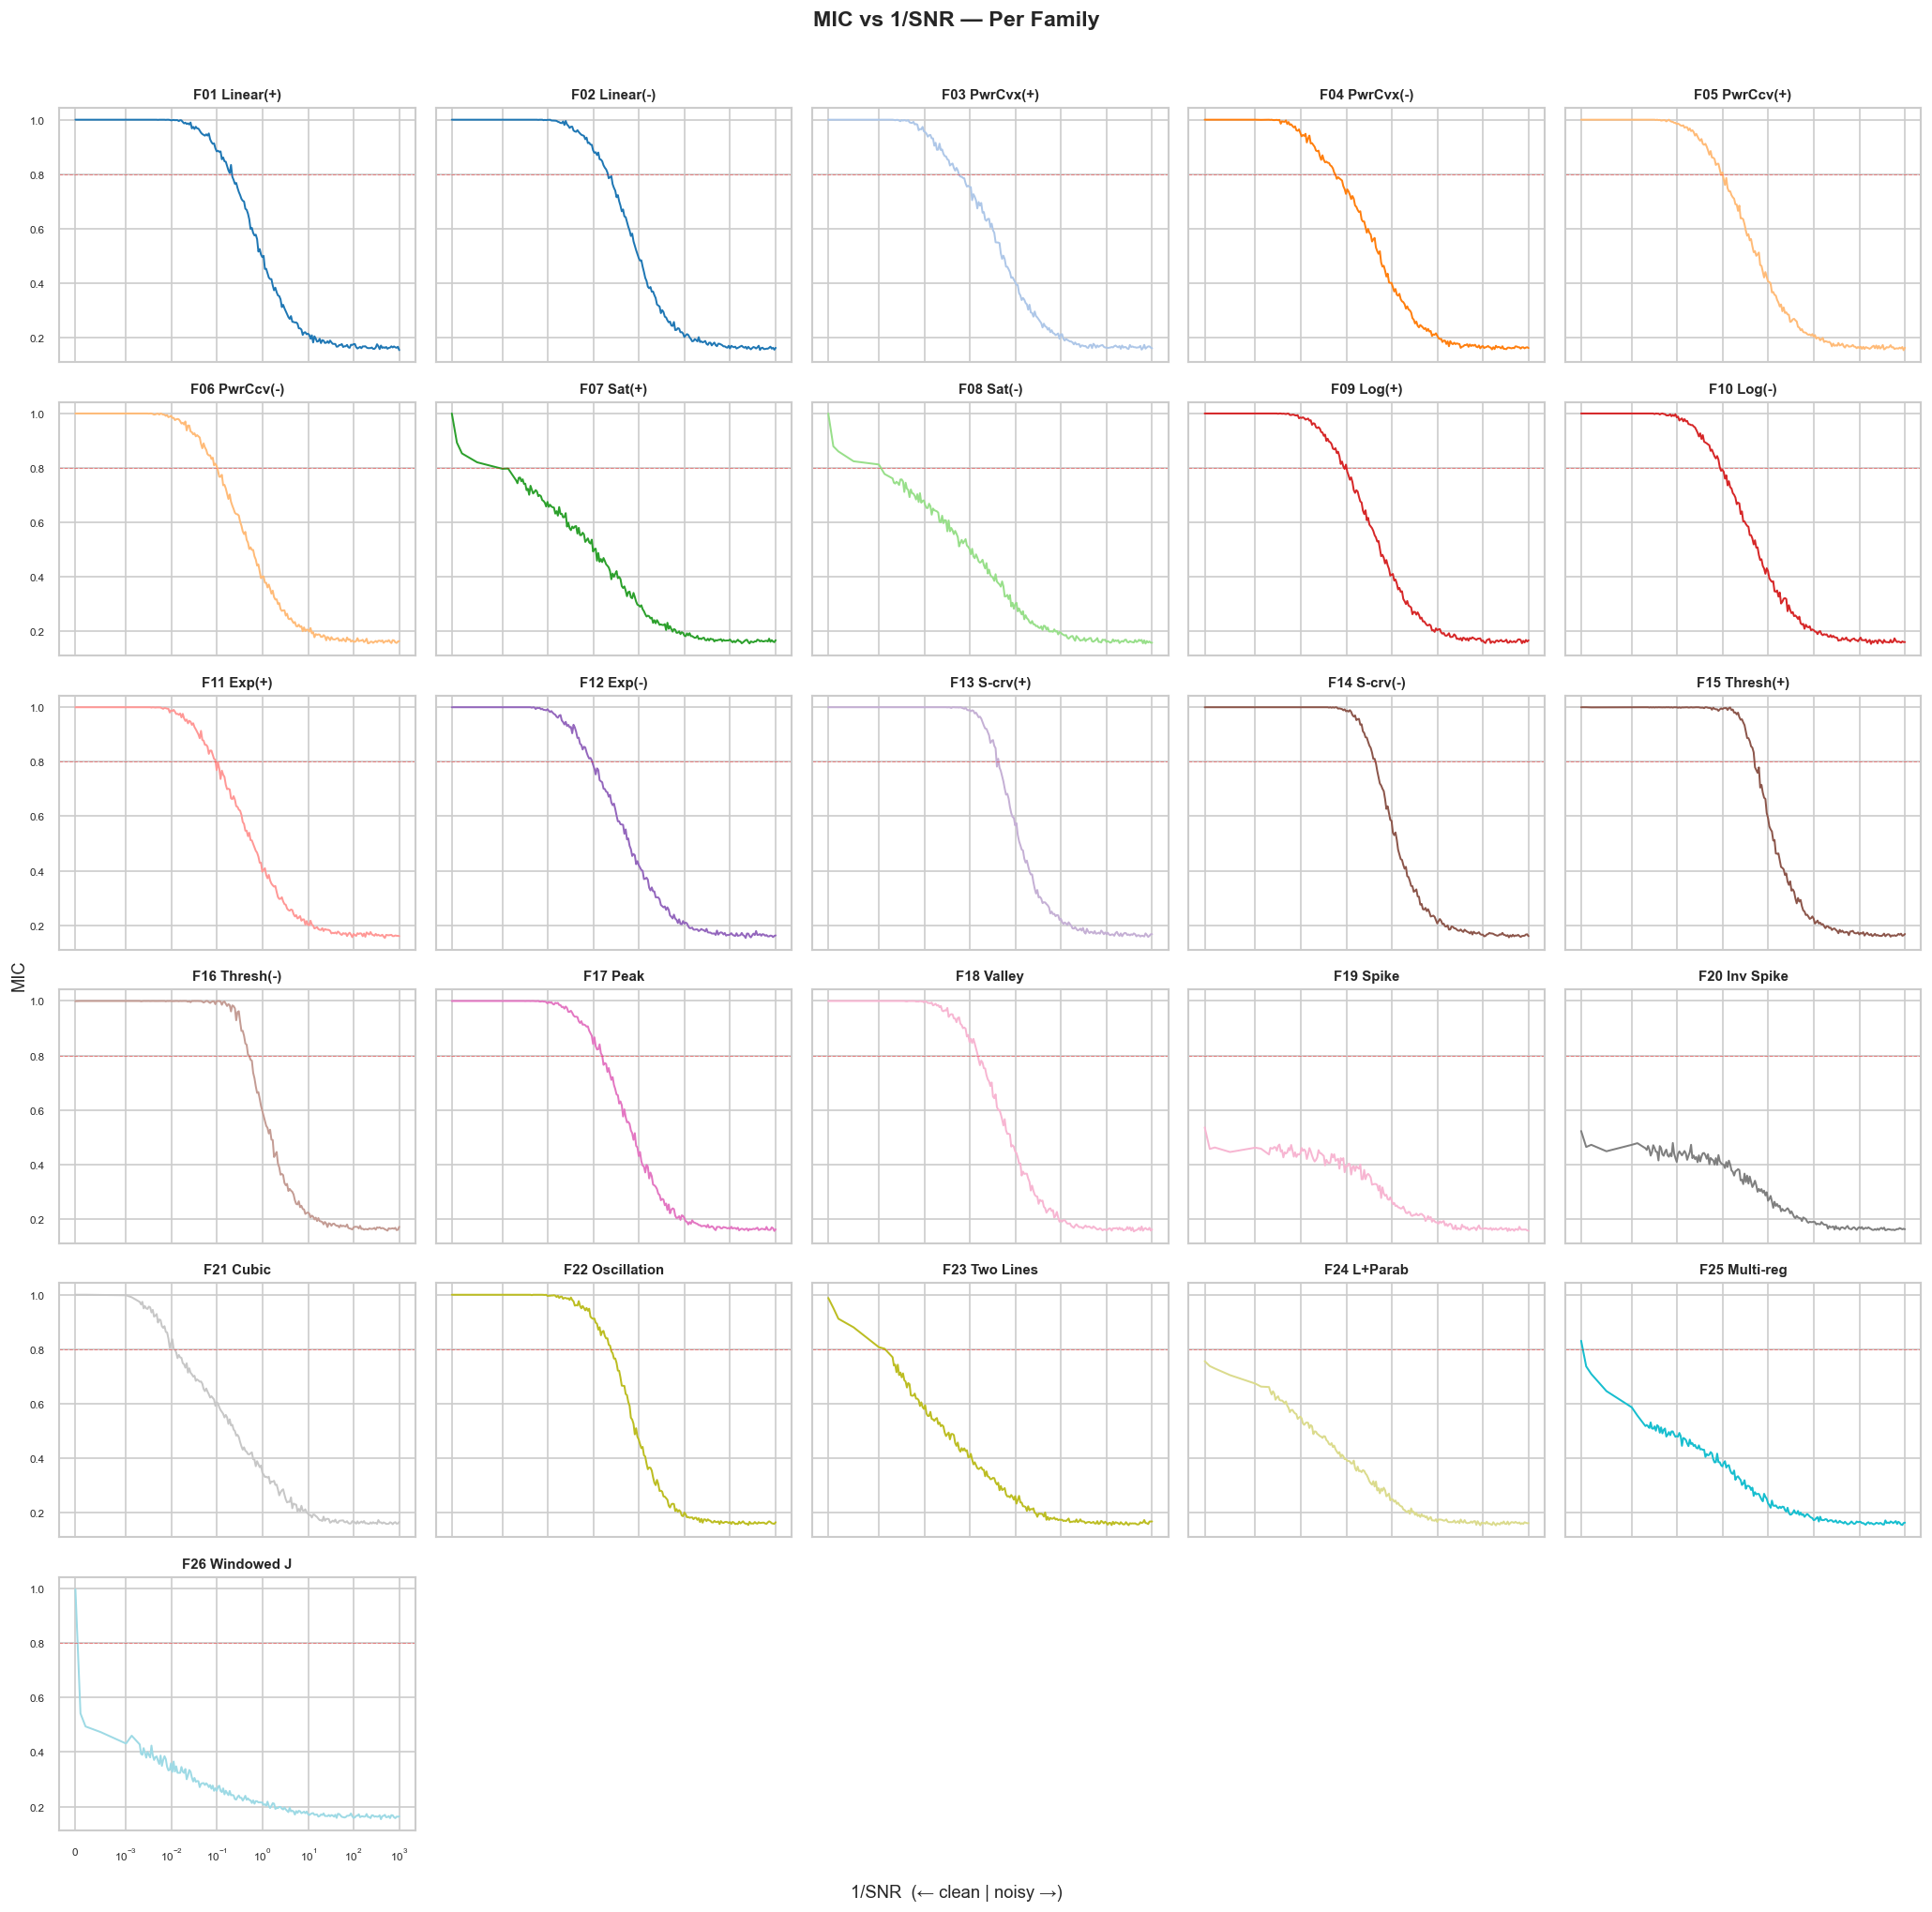

In [7]:
# ── Plot: faceted by family (small multiples) ──
ncols = 5
nrows = (len(fids) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows),
                         sharex=True, sharey=True)
axes_flat = axes.ravel()

for i, fid in enumerate(fids):
    ax = axes_flat[i]
    sub = agg[agg['family_id'] == fid].sort_values('inv_snr')
    ax.plot(sub['inv_snr'], sub['MIC'], linewidth=1.2, color=colors[fid])
    ax.axhline(y=0.8, color='red', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.set_title(f'{fid} {SHORT.get(fid, fid)}', fontsize=9, fontweight='bold')
    ax.set_xscale('symlog', linthresh=0.001)
    ax.tick_params(labelsize=7)

for j in range(len(fids), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('MIC vs 1/SNR — Per Family', fontsize=14, fontweight='bold', y=1.01)
fig.supxlabel('1/SNR  (← clean | noisy →)', fontsize=11)
fig.supylabel('MIC', fontsize=11)
plt.tight_layout()
plt.show()